<a href="https://colab.research.google.com/github/datafreak-adi/practice_ignore/blob/origin/Multicollinearity(task_53).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

Use the famous boston dataset and find out if there is multicollinearity or not. If there is multicollinearity try to remove it with help of steps taught in the session.

In [3]:
import pandas as pd
df= pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv")

In [4]:
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


#Method 1:

Using Heatmap

<Axes: >

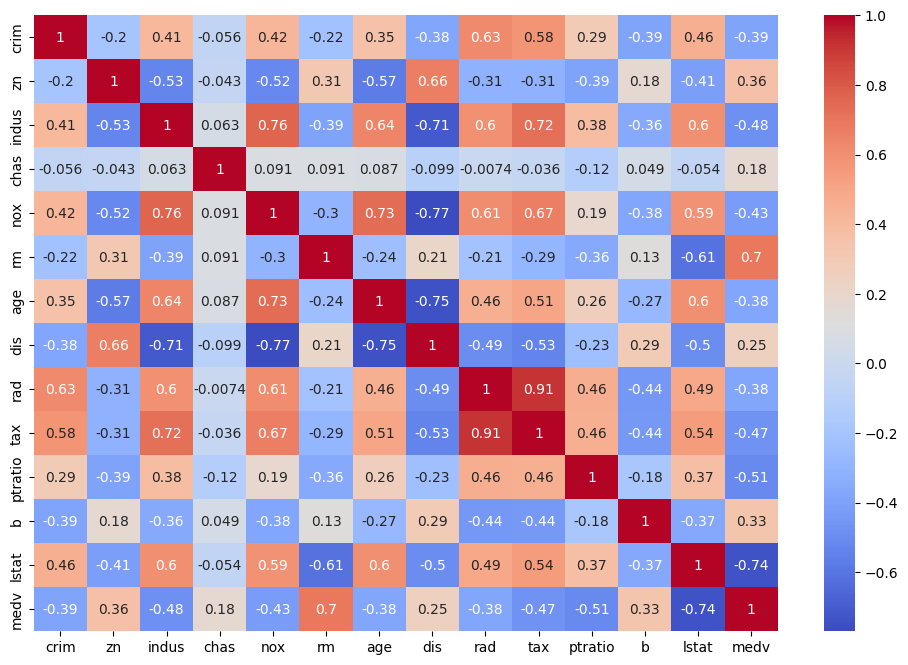

In [5]:
plt.figure(figsize=(12, 8))

corre_matrix= df.corr()
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

In [7]:
corre_matrix

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


In first go, we use the method of removing highly correlated variables

##NOTE:

###Step 1: Identify Highly Correlated Feature Pairs (Multicollinearity):

We're looking for pairs of features that are highly correlated with each other (correlation ≥ 0.8). This is important because having highly correlated features can cause multicollinearity issues, which can harm model performance.

###Step 2: Decide Which Feature to Remove:

Since both features in the pair provide similar information, we only need to keep one of them. To decide which one to keep, we choose the feature that has a stronger relationship with the target variable because it's likely to be more useful for predictions.



In [34]:
# contains the set function
from builtins import set


In [40]:

# Example: Removing highly correlated features based on a threshold of 0.7
threshold = 0.8

# Identify the highly correlated feature pairs
#[:-1, :-1]: Excludes the last row and last column, which might correspond to the target variable (medv) or to avoid self-correlation.

high_corr_features = np.where(np.abs(corre_matrix.values[:-1,:-1]) >= threshold)

feature_to_remove= set()
column_name=[]

#  zip(*high_corr_features) is used for proper variable unpacking , as high_corrr return a tuple having separate row and column indicies

for i, j in zip(*high_corr_features):
   if i!=j and i not in feature_to_remove and j not in feature_to_remove:
    #NOTE: Here we now remove the feature which is less corelated with the independent feature among the two.
          # Since, the two feature i,j are highly corelated with each other so droping the one which is less correlated with output column reduces redudancy(as two columns conveying same info is of no use)

     feature_to_remove.add(j if np.abs(corre_matrix["medv"].iloc[i]>np.abs(corre_matrix["medv"].iloc[j])) else i)
     column_name.append(df.columns[j]) if np.abs(corre_matrix["medv"].iloc[i]>np.abs(corre_matrix["medv"].iloc[j])) else column_name.append(df.columns[i])


print(f" Dropped column :{column_name} with index: {feature_to_remove}")

filtered_df= df.drop(df.columns[list(feature_to_remove)], axis=1)





 Dropped column :['rad'] with index: {8}


In [41]:
filtered_df

,crim,zn,indus,chas,nox,rm,age,dis,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,273,21.0,393.45,6.48,22.0


### Second Method:

Using Variation Inflation factor

In [70]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

independent_features_table= df.drop("medv", axis=1)

vif_score=[]

vif= pd.DataFrame({"Features" : independent_features_table.columns})

for i in range(independent_features_table.shape[1]):

    vif_score.append(variance_inflation_factor(independent_features_table.values,i))

# Filtering dataset with VIF greater than 5

vif["vif_score"]= vif_score


high_corr_columns= vif[vif["vif_score"]>5]

vif_filtered_df= df.drop(high_corr_columns["Features"], axis=1)

vif_filtered_df


,crim,zn,chas,medv
0,0.00632,18.0,0,24.0
1,0.02731,0.0,0,21.6
2,0.02729,0.0,0,34.7
3,0.03237,0.0,0,33.4
4,0.06905,0.0,0,36.2
...,...,...,...,...
501,0.06263,0.0,0,22.4
502,0.04527,0.0,0,20.6
503,0.06076,0.0,0,23.9
504,0.10959,0.0,0,22.0


# Method 3
Using Condition Number

In [77]:
df_cond= df.drop("medv", axis=1)

In [78]:
arr =df.to_numpy()


In [79]:
np.linalg.cond(arr)

8511.919768131662

In [86]:
def remove_high_corr_column(X, threshold):
  corr_num= np.linalg.cond(X)
  if(corr_num> threshold):
    return X

  for i in range (X.shape[1]):
    X_temp= X.drop(X.coumns[i], axis=1)
    con_temp=np.linalg.cond(X_temp)
    if (con_temp<threshold):
      return remove_high_corr_column(X_temp, threshold)

#If none of the features can be removed to bring the condition number below the threshold, the function returns the original matrix X.
  return X






In [89]:
threshold=30

df_reduced_matrix= remove_high_corr_column(df_cond,threshold)

np.linalg.cond(df_reduced_matrix)

8497.936303845774